# Análise visual: curvas de densidade (MoSS 70/30 vs datasets binários locais)

Este notebook faz o fluxo pedido:
1. Carrega `moss_binario_lite.pkl`;
2. Encontra a prevalência MoSS mais próxima de **70/30** (neg/pos = 0.70/0.30);
3. Usa os datasets binários locais em `datasets/binary`;
4. Gera batches 70/30 com o APP;
5. Compara visualmente as curvas de densidade dos scores reais vs MoSS.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

SEED = 42
BATCH_SIZE = 100
N_PREV = 19
REPEATS = 30
TARGET_POS_PREV = 0.30

# Ajuste para o seu ambiente, se necessário
MOSS_PKL = '/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss/lite/moss_binario_lite.pkl'
DATASETS_ROOT = '/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary'

np.random.seed(SEED)

if not os.path.exists(MOSS_PKL):
    raise FileNotFoundError(f'MoSS PKL não encontrado: {MOSS_PKL}')
if not os.path.isdir(DATASETS_ROOT):
    raise FileNotFoundError(f'Pasta de datasets binários não encontrada: {DATASETS_ROOT}')

datasets = sorted([f for f in os.listdir(DATASETS_ROOT) if f.endswith('.csv')])
if not datasets:
    raise RuntimeError(f'Nenhum CSV encontrado em: {DATASETS_ROOT}')

print(f'Datasets binários encontrados: {len(datasets)}')


Datasets binários encontrados: 119


In [2]:
# Implementação do APP (conforme solicitado)
def generate_prevalences(n_prev, repeats):
    prevalences = np.linspace(0.05, 0.95, n_prev)
    return [[1 - p, p] for p in prevalences] * repeats

def sample_batch(y, prevalence, batch_size):
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    n_pos = int(batch_size * prevalence[1])
    idx = np.concatenate([
        np.random.choice(pos, n_pos, replace=True),
        np.random.choice(neg, batch_size - n_pos, replace=True)
    ])
    np.random.shuffle(idx)
    return idx

class APP:
    def __init__(self):
        self.prevs = generate_prevalences(N_PREV, REPEATS)

    def split(self, X, y):
        for p in self.prevs:
            yield sample_batch(y, p, BATCH_SIZE), p

app = APP()
target_prev = [1 - TARGET_POS_PREV, TARGET_POS_PREV]
print('Prevalência alvo APP (neg,pos):', target_prev)
print('Existe no grid?', any(np.isclose(p[1], TARGET_POS_PREV) for p in app.prevs))


Prevalência alvo APP (neg,pos): [0.7, 0.3]
Existe no grid? True


In [3]:
def scalar_prev_from_moss_key(key):
    # chave possível: float ou tupla/lista com prevalência
    if isinstance(key, (int, float, np.floating)):
        return float(key)

    if isinstance(key, (tuple, list)):
        first = key[0]
        if isinstance(first, (int, float, np.floating)):
            return float(first)
        if isinstance(first, (tuple, list, np.ndarray)) and len(first) >= 2:
            return float(first[0])

    raise ValueError(f'Formato de chave MoSS não suportado: {key}')

def to_score_vector(curve):
    arr = np.asarray(curve)
    if arr.ndim == 1:
        return arr.astype(float)
    return arr[:, 0].astype(float)

with open(MOSS_PKL, 'rb') as f:
    moss_data = pickle.load(f)

moss_map = {}
for key, curves in moss_data.items():
    neg_prev = scalar_prev_from_moss_key(key)
    scores = np.concatenate([to_score_vector(c) for c in curves])
    moss_map[neg_prev] = scores

target_neg_prev = 0.70
chosen_neg_prev = min(moss_map.keys(), key=lambda p: abs(p - target_neg_prev))
moss_scores_7030 = moss_map[chosen_neg_prev]

print(f'Prevalência MoSS escolhida (neg): {chosen_neg_prev:.3f}')
print(f'Scores MoSS usados: {len(moss_scores_7030)}')


Prevalência MoSS escolhida (neg): 0.714
Scores MoSS usados: 2000


In [4]:
def kde_curve(scores, grid):
    scores = np.asarray(scores, dtype=float)
    if len(scores) < 2 or np.allclose(scores.std(), 0):
        return np.zeros_like(grid)
    try:
        return gaussian_kde(scores)(grid)
    except Exception:
        return np.zeros_like(grid)

def load_local_binary_dataset(path):
    df = pd.read_csv(path)
    y = df.iloc[:, -1].values
    X = df.iloc[:, :-1].values

    classes = np.unique(y)
    if len(classes) != 2:
        raise ValueError(f'Dataset não binário: {path}')

    # garante rótulo positivo = 1
    y = (y == classes.max()).astype(int)

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.5, stratify=y, random_state=SEED
    )

    scaler = StandardScaler().fit(Xtr)
    Xtr = scaler.transform(Xtr)
    Xte = scaler.transform(Xte)
    return Xtr, Xte, ytr, yte

def real_scores_app_7030(ds_csv):
    Xtr, Xte, ytr, yte = load_local_binary_dataset(ds_csv)

    clf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, ytr)

    batches = []
    for idx, p in app.split(Xte, yte):
        if np.isclose(p[1], TARGET_POS_PREV):
            batches.append(clf.predict_proba(Xte[idx])[:, 1])

    if not batches:
        raise RuntimeError('APP não gerou batches para a prevalência alvo 70/30')

    return np.concatenate(batches)


In [5]:
# Opcional: limitar número de datasets para análise rápida
MAX_DATASETS = None  # coloque None para usar todos
selected = datasets[:MAX_DATASETS] if MAX_DATASETS is not None else datasets

grid = np.linspace(0, 1, 300)
moss_kde = kde_curve(moss_scores_7030, grid)

rows = []
for ds in selected:
    ds_path = os.path.join(DATASETS_ROOT, ds)
    try:
        real_scores = real_scores_app_7030(ds_path)
        real_kde = kde_curve(real_scores, grid)
        l1 = float(np.mean(np.abs(real_kde - moss_kde)))

        rows.append({
            'dataset': ds,
            'n_real_scores': len(real_scores),
            'n_moss_scores': len(moss_scores_7030),
            'kde_l1': l1,
            'real_scores': real_scores,
            'real_kde': real_kde
        })
    except Exception as e:
        print(f'[WARN] {ds}: {e}')

results = pd.DataFrame([{k: v for k, v in r.items() if k not in ['real_scores', 'real_kde']} for r in rows])
results = results.sort_values('kde_l1').reset_index(drop=True)
results.head(10)


KeyboardInterrupt: 

In [ ]:
# Salvar ranking resumido
OUT_DIR = Path('results/exp_015_density_notebook')
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUT_DIR / 'density_comparison_summary.csv'
results.to_csv(summary_path, index=False)
print('Resumo salvo em:', summary_path)


Resumo salvo em: results/exp_015_density_notebook/density_comparison_summary.csv


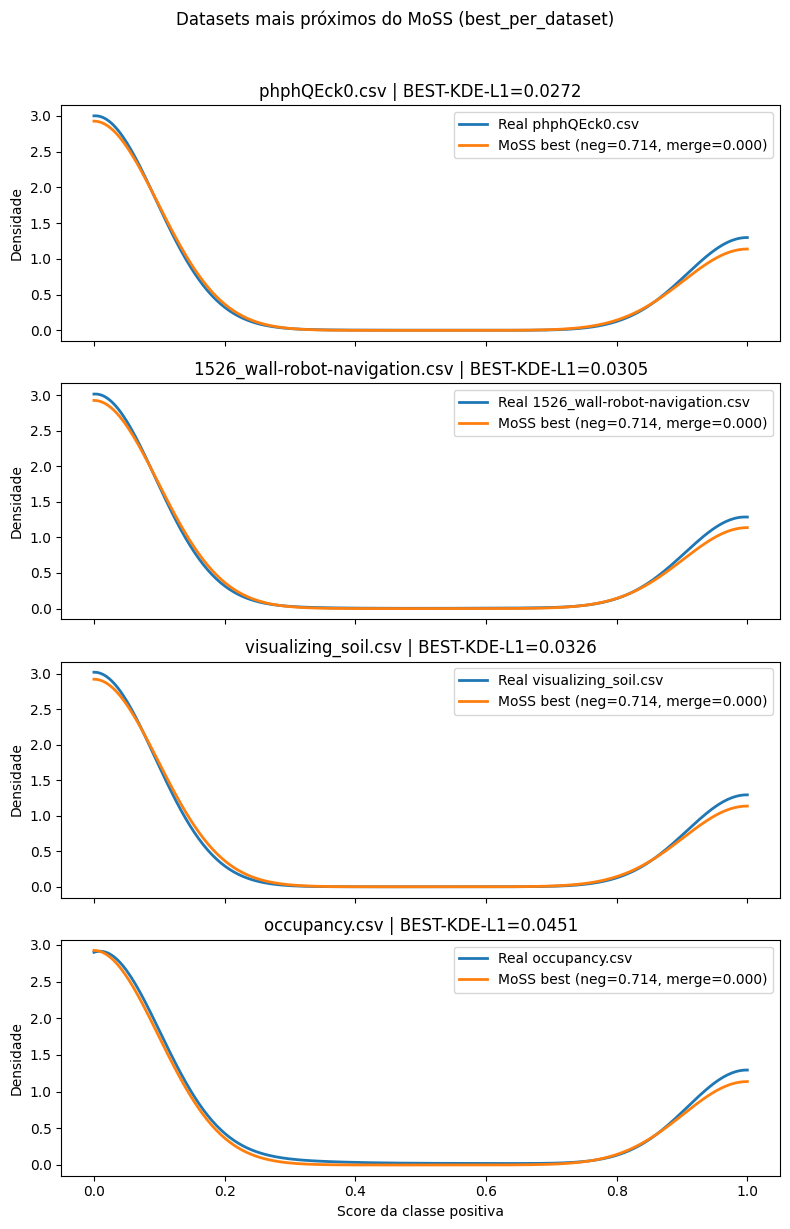

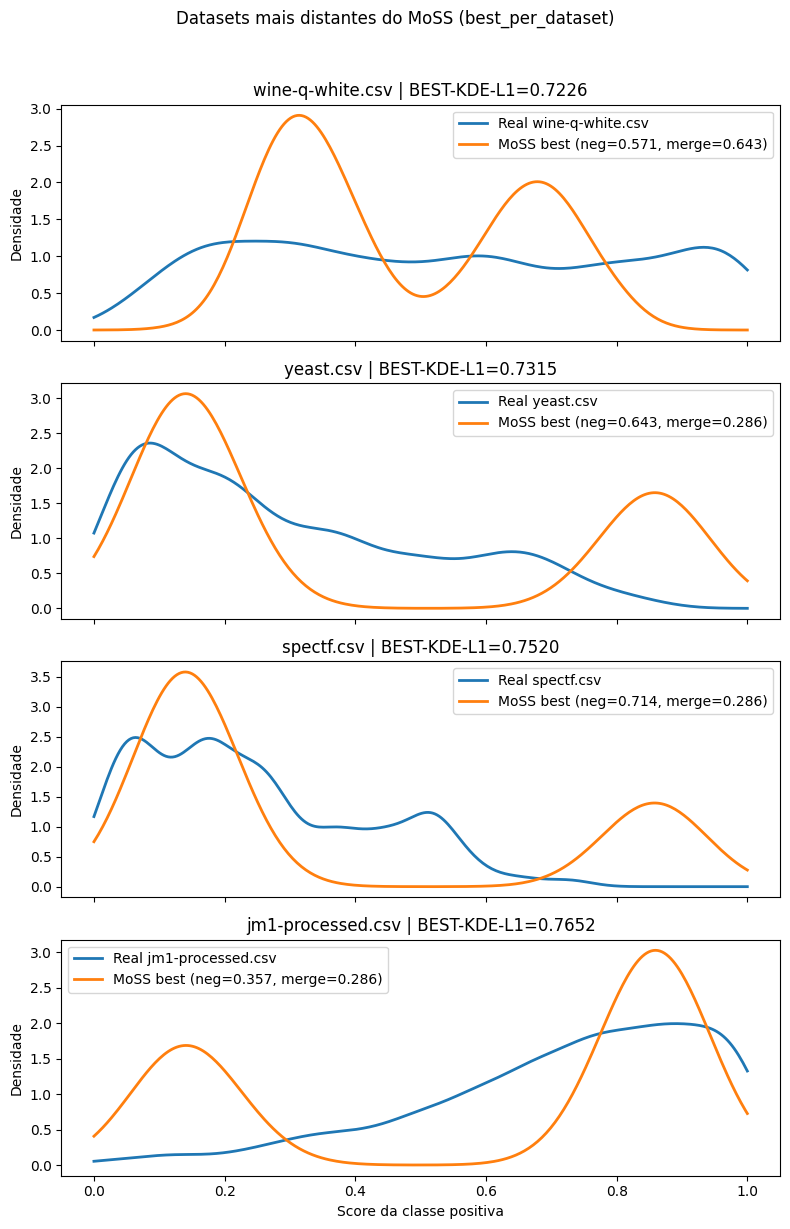

,dataset,best_moss_prev_neg,best_moss_merge,best_kde_l1
92,phphQEck0.csv,0.7143,0.0000,0.027199
12,1526_wall-robot-navigation.csv,0.7143,0.0000,0.030457
110,visualizing_soil.csv,0.7143,0.0000,0.032566
83,occupancy.csv,0.7143,0.0000,0.045104
90,phpMD2hR6.csv,0.7143,0.0000,0.054813
34,BNG.csv,0.7143,0.0000,0.063506
35,BNG_breast-w.csv,0.7143,0.0000,0.063984
43,balloon.csv,0.7143,0.0000,0.066919
98,pollen.csv,0.5000,0.8571,0.077250
9,1497_wall-robot-navigation.csv,0.7143,0.0714,0.088735


In [ ]:
# ==========================================
# MODO DUPLO DE COMPARAÇÃO MoSS:
# - fixed_7030: referência fixa (~70/30)
# - best_per_dataset: melhor curva MoSS por dataset (mínimo KDE-L1)
# ==========================================

TOPK = 4
mode = 'best_per_dataset'   # ou 'fixed_7030'

if len(rows) == 0:
    raise RuntimeError('Nenhum dataset processado com sucesso')

# --------------------------------------------------
# 1) Reconstroi mapa MoSS com chave COMPLETA:
#    (neg_prev, merge) -> scores agregados (todas curvas daquele bloco)
# --------------------------------------------------
# Pré-requisito: moss_data já carregado no notebook
# com:
# with open(MOSS_PKL, 'rb') as f:
#     moss_data = pickle.load(f)

def to_score_vector(curve):
    arr = np.asarray(curve)
    if arr.ndim == 1:
        return arr.astype(float)
    return arr[:, 1].astype(float)  # score da classe positiva

moss_kde_map = {}   # (neg_prev, merge) -> kde
moss_scores_map = {}  # opcional: guardar scores

for key, curves in moss_data.items():
    # key esperado: ((p_neg, p_pos), merge)
    alpha_key, merge = key
    neg_prev = float(alpha_key[0])
    merge = float(merge)

    # agrega todas as curvas do bloco (neg_prev, merge)
    block_scores = np.concatenate([to_score_vector(c) for c in curves])
    moss_scores_map[(neg_prev, merge)] = block_scores
    moss_kde_map[(neg_prev, merge)] = kde_curve(block_scores, grid)

if len(moss_kde_map) == 0:
    raise RuntimeError("moss_kde_map vazio. Verifique formato de moss_data.")

# --------------------------------------------------
# 2) Referência fixa 70/30 agora também usa (neg_prev, merge)
#    pega o bloco mais próximo de neg=0.70
# --------------------------------------------------
target_neg = 0.70
fixed_key = min(moss_kde_map.keys(), key=lambda k: abs(k[0] - target_neg))
moss_kde_fixed = moss_kde_map[fixed_key]

# --------------------------------------------------
# 3) Best per dataset procurando em TODAS as chaves (neg_prev, merge)
# --------------------------------------------------
def attach_best_moss(rows_in):
    out = []
    keys = list(moss_kde_map.keys())

    for r in rows_in:
        real_kde = r['real_kde']
        best_key, best_l1 = None, np.inf

        for k in keys:
            mkde = moss_kde_map[k]
            l1 = float(np.mean(np.abs(real_kde - mkde)))
            if l1 < best_l1:
                best_l1 = l1
                best_key = k

        r2 = dict(r)
        r2['best_moss_prev_neg'] = float(best_key[0])
        r2['best_moss_merge'] = float(best_key[1])
        r2['best_kde_l1'] = float(best_l1)
        out.append(r2)

    return out

rows_best = attach_best_moss(rows)

if mode == 'fixed_7030':
    # mantém ranking antigo para comparação direta
    rows_ranked = sorted(rows, key=lambda r: r['kde_l1'])
elif mode == 'best_per_dataset':
    rows_ranked = sorted(rows_best, key=lambda r: r['best_kde_l1'])
else:
    raise ValueError("mode deve ser 'fixed_7030' ou 'best_per_dataset'")

best = rows_ranked[:TOPK]
worst = rows_ranked[-TOPK:]

def get_moss_kde_for_row(row, mode='fixed_7030'):
    if mode == 'fixed_7030':
        lbl = f"MoSS fixo (neg={fixed_key[0]:.3f}, merge={fixed_key[1]:.3f})"
        return moss_kde_fixed, lbl
    else:
        k = (row['best_moss_prev_neg'], row['best_moss_merge'])
        lbl = f"MoSS best (neg={k[0]:.3f}, merge={k[1]:.3f})"
        return moss_kde_map[k], lbl

def row_l1_text(row, mode='fixed_7030'):
    if mode == 'fixed_7030':
        return f"KDE-L1={row['kde_l1']:.4f}"
    return f"BEST-KDE-L1={row['best_kde_l1']:.4f}"

def plot_group(group, title, mode='fixed_7030'):
    n = len(group)
    fig, axes = plt.subplots(n, 1, figsize=(8, 3*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, row in zip(axes, group):
        mkde, moss_label = get_moss_kde_for_row(row, mode=mode)
        ax.plot(grid, row['real_kde'], label=f"Real {row['dataset']}", linewidth=2)
        ax.plot(grid, mkde, label=moss_label, linewidth=2)
        ax.set_ylabel('Densidade')
        ax.set_title(f"{row['dataset']} | {row_l1_text(row, mode)}")
        ax.legend()

    axes[-1].set_xlabel('Score da classe positiva')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_group(best, f"Datasets mais próximos do MoSS ({mode})", mode=mode)
plot_group(worst, f"Datasets mais distantes do MoSS ({mode})", mode=mode)

if mode == 'best_per_dataset':
    summary_best = pd.DataFrame([
        {
            'dataset': r['dataset'],
            'best_moss_prev_neg': r['best_moss_prev_neg'],
            'best_moss_merge': r['best_moss_merge'],
            'best_kde_l1': r['best_kde_l1'],
        }
        for r in rows_best
    ]).sort_values('best_kde_l1')
    display(summary_best.head(15))


In [ ]:
# ============================================================
# Comparar "piores datasets" (exp_009 erro real) vs KDE-L1 atual
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import plotly.express as px

EXP009_CSV = "/var/new_homes/julio/mestrado/mestrado-dyssyn/experiments/exp_009/results/comparacao_moss_feature_sets_30.csv"

if not os.path.exists(EXP009_CSV):
    raise FileNotFoundError(f"Arquivo não encontrado: {EXP009_CSV}")

# 1) Base do KDE atual (espera summary_best da célula anterior)
if "summary_best" in globals():
    kde_df = summary_best.copy()
elif "rows_best" in globals():
    kde_df = pd.DataFrame(rows_best)[["dataset", "best_moss_prev_neg", "best_moss_merge", "best_kde_l1"]].copy()
else:
    raise RuntimeError("Não encontrei summary_best nem rows_best no ambiente.")

# 2) Carregar resultados exp_009
exp009 = pd.read_csv(EXP009_CSV)

required_cols = {"dataset", "erro"}
missing = required_cols - set(exp009.columns)
if missing:
    raise ValueError(f"CSV exp_009 sem colunas esperadas: {missing}")

# 3) Normalização de nomes de dataset para facilitar match
def norm_ds(x):
    x = str(x).strip().lower()
    x = re.sub(r"\.csv$", "", x)
    return x

kde_df["dataset_norm"] = kde_df["dataset"].map(norm_ds)
exp009["dataset_norm"] = exp009["dataset"].map(norm_ds)

# 4) Agregar exp_009 por dataset (erro médio)
exp009_agg = (
    exp009.groupby("dataset_norm", as_index=False)
    .agg(
        erro_exp009_mean=("erro", "mean"),
        erro_exp009_median=("erro", "median"),
        n_exp009=("erro", "size"),
        dataset_exp009=("dataset", "first"),
    )
)

# 5) Merge com resultados KDE
cmp_df = kde_df.merge(exp009_agg, on="dataset_norm", how="inner")

if cmp_df.empty:
    raise RuntimeError(
        "Nenhum dataset em comum entre summary_best e exp_009 após normalização."
    )

# 6) Correlações (quanto maior, mais "explicável")
pearson = cmp_df["best_kde_l1"].corr(cmp_df["erro_exp009_mean"], method="pearson")
spearman = cmp_df["best_kde_l1"].corr(cmp_df["erro_exp009_mean"], method="spearman")

print(f"Datasets comparados: {len(cmp_df)}")
print(f"Correlação Pearson (best_kde_l1 vs erro_exp009_mean): {pearson:.4f}")
print(f"Correlação Spearman (ranking): {spearman:.4f}")

# 7) Sobreposição dos piores
TOPK = min(15, len(cmp_df))

worst_kde = cmp_df.sort_values("best_kde_l1", ascending=False).head(TOPK)
worst_exp009 = cmp_df.sort_values("erro_exp009_mean", ascending=False).head(TOPK)

set_kde = set(worst_kde["dataset_norm"])
set_exp = set(worst_exp009["dataset_norm"])
overlap = sorted(set_kde & set_exp)

print(f"\nTop-{TOPK} piores por KDE-L1: {len(set_kde)}")
print(f"Top-{TOPK} piores por erro exp_009: {len(set_exp)}")
print(f"Sobreposição: {len(overlap)} datasets")
print("Datasets em comum:", overlap)

# 8) Tabela final para inspeção
display_cols = [
    "dataset", "best_moss_prev_neg", "best_moss_merge", "best_kde_l1",
    "erro_exp009_mean", "erro_exp009_median", "n_exp009"
]
display(cmp_df[display_cols].sort_values("erro_exp009_mean", ascending=False).head(25))

# 9) Scatter para diagnóstico visual
fig = px.scatter(
    cmp_df,
    x="best_kde_l1",
    y="erro_exp009_mean",
    hover_name="dataset",
    trendline="ols",
    title="Relação entre pior ajuste KDE e erro observado no exp_009",
    labels={
        "best_kde_l1": "best_kde_l1 (menor é melhor)",
        "erro_exp009_mean": "erro médio exp_009 (menor é melhor)",
    },
)
fig.show()


Datasets comparados: 119
Correlação Pearson (best_kde_l1 vs erro_exp009_mean): 0.0877
Correlação Spearman (ranking): 0.0909

Top-15 piores por KDE-L1: 15
Top-15 piores por erro exp_009: 15
Sobreposição: 1 datasets
Datasets em comum: ['spectf']


,dataset,best_moss_prev_neg,best_moss_merge,best_kde_l1,erro_exp009_mean,erro_exp009_median,n_exp009
83,1541_volcanoes-d4.csv,0.1429,0.0000,0.492382,0.399277,0.360711,2850
79,1538_volcanoes-d1.csv,0.1429,0.0000,0.479128,0.392478,0.340744,2850
77,1540_volcanoes-d3.csv,0.1429,0.0000,0.467618,0.390048,0.343125,2850
73,1539_volcanoes-d2.csv,0.1429,0.0714,0.444728,0.375616,0.329789,2850
51,puma32H.csv,0.6429,0.6429,0.308103,0.369540,0.338475,2850
69,1507_twonorm.csv,0.5714,0.2143,0.412079,0.364665,0.337632,2850
117,spectf.csv,0.7143,0.2857,0.752046,0.364290,0.331673,2850
68,phpxijhaP.csv,0.5714,0.2143,0.410020,0.362158,0.323801,2850
43,bank8FM.csv,0.6429,0.1429,0.252289,0.360745,0.336375,2850
96,click-prediction.csv,0.2143,0.2857,0.582923,0.356598,0.315121,2850
